In [1]:
import math
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import logging


from astropy import constants
from burnman import minerals, Composite

In [4]:
%load_ext autoreload
%autoreload 2

import geotherm_calculator as gc
import habitability_calculator as hc
import planetary_grid_reader as pgr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
logger = logging.getLogger(__name__)
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(levelname)s: %(message)s"))
    logger.addHandler(handler)
logger.setLevel(logging.WARNING)  # cambia a INFO/DEBUG si quieres más detalle

In [6]:
# ---------- CACHES GLOBALES ----------
_SINGLE_COMPOSITE_CACHE = {}      # cache para Composite de mineral unitario {name: Composite}
_MINERAL_COMPOSITE_CACHE = {}     # cache para Composite mixto creado por make_composite_from_modal si deseas

In [7]:
def plot_geotherm_profile(df):
    """
    Grafica el perfil geotérmico a partir del DataFrame resultante de calculate_geotherm.
    """
    # 1. Crear copias/conversiones de unidades para las gráficas
    depth_km = df['depth_m'] / 1000.0
    T_K = df['T_K']
    P_GPa = df['P_Pa'] / 1e9
    rho = df['rho_kg_m3']
    lambda_k = df['lambda_W_mK']
    q_mW = df['q_W_m2'] * 1000.0
    phi = df['phi']
    
    # 2. Encontrar las profundidades donde cambia la capa para dibujar fronteras
    # Comparamos la capa actual con la anterior para encontrar el índice de cambio
    layer_changes = df[df['layer'] != df['layer'].shift(1)]
    # Omitimos el primer valor (superficie)
    boundaries_km = layer_changes['depth_m'].iloc[1:] / 1000.0
    
    # 3. Configurar la figura (1 fila, 6 columnas)
    fig, axes = plt.subplots(1, 6, figsize=(18, 8), sharey=True)
    
    # Variables a graficar: (Datos X, Título, Etiqueta X, Color)
    plots = [
        (T_K, 'Temperature', 'T [K]', 'crimson'),
        (P_GPa, 'Pressure', 'P [GPa]', 'darkblue'),
        (rho, 'Density', 'ρ [kg/m³]', 'forestgreen'),
        (lambda_k, 'Thermal Conductivity', 'λ [W/m·K]', 'darkorange'),
        (q_mW, 'Heat Flux', 'q [mW/m²]', 'purple'),
        (phi, 'Porosity', 'φ [fraction]', 'teal')
    ]
    
    # 4. Generar cada subplot
    for ax, (x_data, title, xlabel, color) in zip(axes, plots):
        ax.plot(x_data, depth_km, color=color, linewidth=2.5)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Dibujar líneas horizontales para las fronteras de las capas
        for b_km in boundaries_km:
            ax.axhline(y=b_km, color='black', linestyle=':', alpha=0.5)
            
    # Configurar el eje Y (compartido)
    axes[0].set_ylabel('Depth [km]', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis() # La superficie arriba
    
    # Añadir los nombres de las capas en el primer gráfico
    # Calculamos el punto medio de cada capa para poner el texto
    all_bounds = [0] + list(boundaries_km) + [depth_km.iloc[-1]]
    unique_layers = df['layer'].unique()
    
    for i in range(len(unique_layers)):
        if i < len(all_bounds) - 1:
            mid_pt = (all_bounds[i] + all_bounds[i+1]) / 2
            axes[0].text(axes[0].get_xlim()[0] + 0.05*(axes[0].get_xlim()[1]-axes[0].get_xlim()[0]), 
                         mid_pt, unique_layers[i], 
                         fontsize=10, color='black', verticalalignment='center',
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
            
    axes[5].set_xscale('log')

    plt.tight_layout()
    plt.show()

### PHYSICAL CONSTANTS / CONSTANTES FÍSICAS


In [8]:

G = constants.G.value  # Gravitational constant / Constante gravitacional
Me = constants.M_earth.value  # Earth mass (kg) / Masa de la Tierra (kg)
Re = constants.R_earth.value  # Earth radius (m) / Radio de la Tierra (m)
km = 1000.0  # meters per kilometer / metros por kilómetro

In [9]:
# =============================================================================
# COMPOSICIONES MODALES POR CAPA (% volumétrico)
# Basadas en Hasterok & Chapman (2011), Rudnick & Gao (2003)
# Los valores se normalizarán automáticamente a suma = 1.0
# =============================================================================

COMPOSITION_DEFAULT = {
    # UPPER CRUST (Corteza Superior Félsica - tipo Granito/Tonalita)
    # Rica en cuarzo y feldespatos, minerales de baja densidad
    "upper": {
        "Quartz": 27,           
        "Orthoclase": 15,       
        "Albite": 32,           
        "Anorthite": 8,         
        "Phlogopite": 5,        
        "Hornblende": 13        
        # Suma: 100% (minerales félsicos + micas + anfíboles)
    },
    
    # MIDDLE CRUST (Corteza Media Intermedia - tipo Diorita)
    # Transición entre félsica y máfica
    # Composición TTG (Tonalite-Trondhjemite-Granodiorite)
    "middle": {
        "Quartz": 15,           
        "Orthoclase": 5,        
        "Albite": 35,          
        "Anorthite": 20,        
        "Hornblende": 20       
        # Suma: 95% (como en Hasterok & Chapman 2011, Table 1)
        # Se normalizará automáticamente
    },
    
    # LOWER CRUST (Corteza Inferior Máfica - tipo Gabro/Granulita)
    # Rica en minerales máficos de alta densidad
    "lower": {
        "Quartz": 2,            
        "Orthoclase": 10,
        "Albite": 10,
        "Anorthite": 18,
        "Hornblende": 47,
        "Diopside": 1,
        "Hedenbergite": 1,
        "Enstatite": 1,
        "Ferrosillite": 1
    },
    
    # MANTLE (Manto Superior - Peridotita Litosférica)
    "mantle": {
        "Diopside": 5.47,
        "Hedenbergite": 0.53,
        "Enstatite": 18.47,
        "Ferrosillite": 1.53,
        "Forsterite": 63.65,
        "Fayalite": 3.35,
        "Pyrope": 5.58,
        "Almandine": 1.42
    }
    
}

# =============================================================================
# PARÁMETROS DE CONDUCTIVIDAD TÉRMICA POR MINERAL
# Basados en Hofmeister (1999), Stackhouse et al. (2015), Hasterok & Chapman (2011)
# 
# lambda0: conductividad a 298 K y 1 bar (W/m·K)
# n: exponente de dependencia térmica (típico 0.4-0.6 para silicatos)
# KT: módulo de incompresibilidad isotérmica (GPa)
# KTp: derivada de presión de KT (adimensional)
# lambdaRmax: conductividad radiativa máxima (W/m·K) - importante T > 1200 K
# TR: temperatura de transición radiativa (K)
# omega: ancho de transición radiativa (K)
# =============================================================================

MINERAL_PARAMS = {
    "Quartz": {"lambda0": 6.5, "n": 0.5, "KT": 60.0, "KTp": 4.0,
               "lambdaRmax": 0.5, "TR": 1400.0, "omega": 300.0},
    "Orthoclase": {"lambda0": 2.5, "n": 0.5, "KT": 60.0, "KTp": 4.0,
                   "lambdaRmax": 0.2, "TR": 1400.0, "omega": 300.0},
    "Albite": {"lambda0": 3.0, "n": 0.5, "KT": 60.0, "KTp": 4.0,
               "lambdaRmax": 0.3, "TR": 1400.0, "omega": 300.0},
    "Anorthite": {"lambda0": 3.5, "n": 0.5, "KT": 70.0, "KTp": 4.0,
                  "lambdaRmax": 0.4, "TR": 1400.0, "omega": 300.0},
    "Phlogopite": {"lambda0": 1.7, "n": 0.4, "KT": 40.0, "KTp": 4.0,
                   "lambdaRmax": 0.1, "TR": 1300.0, "omega": 300.0},
    "Hornblende": {"lambda0": 2.2, "n": 0.5, "KT": 60.0, "KTp": 4.0,
                   "lambdaRmax": 0.5, "TR": 1350.0, "omega": 300.0},
    "Diopside": {"lambda0": 3.8, "n": 0.5, "KT": 105.0, "KTp": 4.3,
                 "lambdaRmax": 1.0, "TR": 1400.0, "omega": 300.0},
    "Hedenbergite": {"lambda0": 3.0, "n": 0.5, "KT": 100.0, "KTp": 4.0,
                     "lambdaRmax": 0.8, "TR": 1350.0, "omega": 300.0},
    "Enstatite": {"lambda0": 4.2, "n": 0.5, "KT": 107.0, "KTp": 4.5,
                  "lambdaRmax": 1.5, "TR": 1300.0, "omega": 300.0},
    "Ferrosillite": {"lambda0": 3.5, "n": 0.5, "KT": 100.0, "KTp": 4.0,
                     "lambdaRmax": 1.0, "TR": 1300.0, "omega": 300.0},
    "Forsterite": {"lambda0": 5.5, "n": 0.6, "KT": 128.0, "KTp": 4.2,
                   "lambdaRmax": 3.0, "TR": 1200.0, "omega": 300.0},
    "Fayalite": {"lambda0": 4.5, "n": 0.5, "KT": 130.0, "KTp": 4.0,
                 "lambdaRmax": 1.5, "TR": 1200.0, "omega": 300.0},
    "Pyrope": {"lambda0": 4.0, "n": 0.6, "KT": 171.0, "KTp": 4.3,
               "lambdaRmax": 2.0, "TR": 1400.0, "omega": 300.0},
    "Almandine": {"lambda0": 3.8, "n": 0.5, "KT": 175.0, "KTp": 4.5,
                  "lambdaRmax": 1.5, "TR": 1400.0, "omega": 300.0}
}


## SOLVER PRINCIPAL: `calculate_geotherm()`

Implementación del **bootstrap method** (Chapman 1986, Hasterok & Chapman 2011) para resolver la ecuación de conducción térmica 1D en estado estacionario:

$$\frac{d}{dz}\left[\lambda(z,T,P) \frac{dT}{dz}\right] + A(z) = 0$$

**Método numérico:**
1. Discretización en capas de espesor `dz`
2. En cada capa se resuelve iterativamente el sistema acoplado:
   - Temperatura: $T_{i+1} = T_i + \frac{q_i}{\lambda_i} \Delta z - \frac{A_i}{2\lambda_i} \Delta z^2$
   - Presión: $P_{i+1} = P_i + \rho_i g_i \Delta z$
   - Densidad: $\rho_i = \rho(T,P,\text{composición})$ (via BurnMan)
3. Iteración hasta convergencia en T y P

## EJEMPLO 1: Geoterma Continental de la Tierra (Presente)

Calcularemos el perfil geotérmico para un continente tipo con parámetros terrestres modernos.

**Parámetros de Referencia (Hasterok & Chapman 2011):**
- Flujo de calor superficial: 65 mW/m² (promedio continental)
- Modelo radiogénico: Exponencial con A₀ = 2.5 μW/m³, h_r = 10 km
- Estructura: Upper (0-16 km), Middle (16-23 km), Lower (23-39 km), Mantle (>39 km)

**Validación Esperada:**
- Gradiente superficial: ~25-30 K/km (primeros 10 km)
- Temperatura al Moho (39 km): ~800-950 K
- LAB depth: ~100-120 km (donde T = 1350 K)

In [13]:
def A0(q_surface, F = 0.60, D = 10.0*km):
    """
    Calcula el área superficial necesaria para disipar un flujo de calor dado.
    
    Parámetros:
    - q_surface: Flujo de calor en la superficie (W/m²)
    - F: Fracción basal
    - D: Espesor de la corteza superior enriquecida [m] (ej. 10000 m = 10 km)
    
    Retorna:
    - A0 en W/m^3
    """
    # Fórmula: A_0 = [(1 - F) * q_s] / D
    A0 = ((1 - F) * q_surface) / D
    
    return A0

In [14]:
# =============================================================================
# PASO 1: Preparar composiciones y objetos minerales
# =============================================================================

mineral_objects = gc.get_mineral_objects()
rocks = gc.prepare_rocks_dict(composition=gc.COMPOSITION_DEFAULT, 
                           mineral_objects=mineral_objects)


# =============================================================================
# PASO 2: Parámetros del cálculo
# =============================================================================

# Parámetros terrestres modernos
q_s_earth = 65e-3          # 65 mW/m² (cratón continental, valor de referencia Hasterok)
z_max = 150e3              # Profundidad máxima: 150 km
dz = 100.0                 # Paso de integración: 100 m
T_surface = 288.0          # Temperatura superficial: 15°C

# Parámetros radiogénicos (modelo exponencial)
# Ajustados para ser consistentes con flujo de calor observado
A_surface = 2.5e-6         # 2.5 μW/m³ 
h_r = 10e3                 # 10 km (profundidad característica típica)

print("\n📊 Parámetros del cálculo:")
print(f"   q_s = {q_s_earth*1000:.1f} mW/m²")
print(f"   A_surface = {A_surface*1e6:.2f} μW/m³")
print(f"   h_r = {h_r/1000:.1f} km")
print(f"   z_max = {z_max/1000:.1f} km")
print(f"   dz = {dz:.1f} m")

# =============================================================================
# PASO 3: Calcular geoterma
# =============================================================================

print("\n🚀 Calculando perfil geotérmico...")
print("=" * 80)

df_earth = gc.calculate_geotherm(
    rocks=rocks,
    q_s=q_s_earth,
    z_max=z_max,
    dz=dz,
    R_planet=Re,
    M_total=Me,
    composition=gc.COMPOSITION_DEFAULT,
    boundaries=gc.scale_layer_boundaries(Re),
    T_top=T_surface,
    radiogenic_model='exponential',
    A_surface=A_surface,
    h_r=h_r,
    DEBUG=False  # Cambiar a True para ver iteraciones
)



📊 Parámetros del cálculo:
   q_s = 65.0 mW/m²
   A_surface = 2.50 μW/m³
   h_r = 10.0 km
   z_max = 150.0 km
   dz = 100.0 m

🚀 Calculando perfil geotérmico...


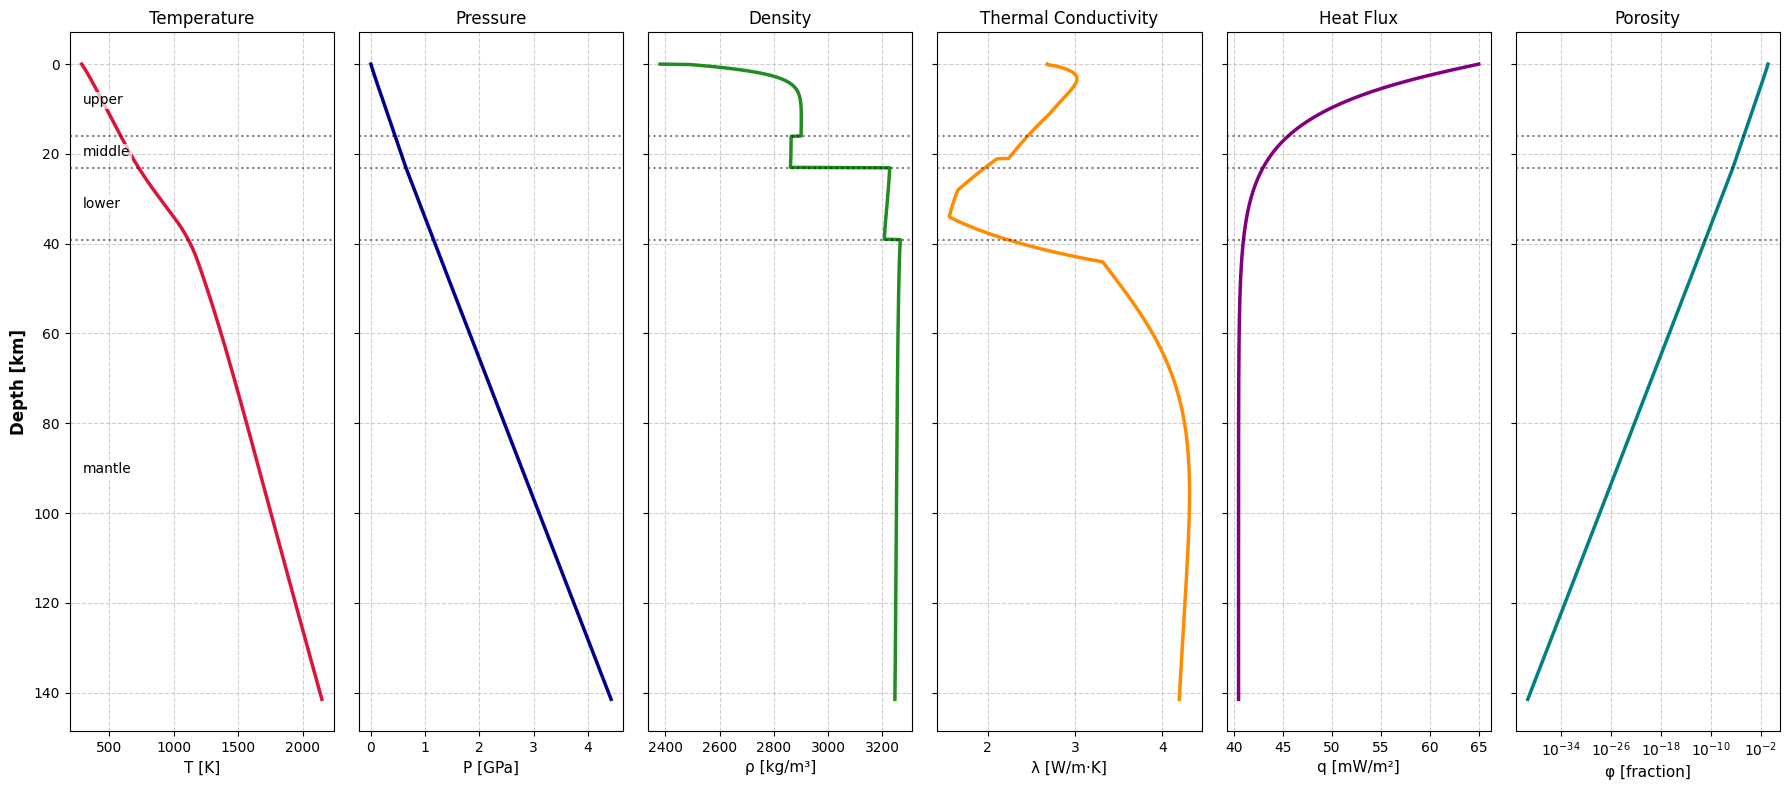

In [9]:
plot_geotherm_profile(df_earth)

In [58]:
qss = np.linspace(30, 120, 10) * 1e-3 
z_max = 150e3
dz = 100.0
T_surface = hc.T_eq(1.0)
data = [ ]

for q in qss:
    print(f"\n🚀 Calculando geoterma para q_s = {q*1000:.1f} mW/m²...")
    df = gc.calculate_geotherm(
        rocks=rocks,
        q_s=q,
        z_max=z_max,
        dz=dz,
        R_planet=Re,
        M_total=Me,
        composition=gc.COMPOSITION_DEFAULT,
        boundaries=gc.scale_layer_boundaries(Re),
        T_top=T_surface,
        radiogenic_model='exponential',
        A_surface=A0(q),
        h_r=h_r,
        DEBUG=False
    )
    
    geoterma_q = df[['depth_m', 'T_K']]
    geoterma_q.attrs['q_W_m2'] = q
    
    data.append(geoterma_q)



🚀 Calculando geoterma para q_s = 30.0 mW/m²...

🚀 Calculando geoterma para q_s = 40.0 mW/m²...

🚀 Calculando geoterma para q_s = 50.0 mW/m²...

🚀 Calculando geoterma para q_s = 60.0 mW/m²...

🚀 Calculando geoterma para q_s = 70.0 mW/m²...

🚀 Calculando geoterma para q_s = 80.0 mW/m²...

🚀 Calculando geoterma para q_s = 90.0 mW/m²...

🚀 Calculando geoterma para q_s = 100.0 mW/m²...

🚀 Calculando geoterma para q_s = 110.0 mW/m²...

🚀 Calculando geoterma para q_s = 120.0 mW/m²...


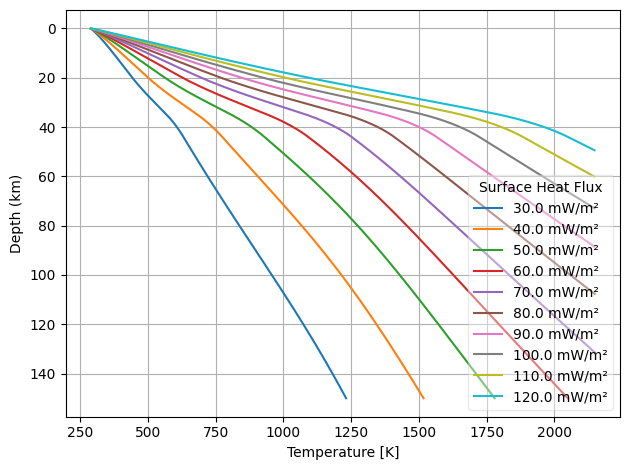

In [59]:
for geo in data:
    plt.plot(geo['T_K'], geo['depth_m']/km, label=f'{geo.attrs["q_W_m2"]*1000:.1f} mW/m²')

plt.xlabel('Temperature [K]')
plt.ylabel('Depth (km)')
plt.legend( title='Surface Heat Flux', loc = 'lower right', framealpha=0.4)
plt.grid()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
    

In [15]:
planetary_grid_path = "PlanetaryGrid"
target_folder = "CMF_0.30-IMF_0.00"
planet = 'M1.00'
folder_path = os.path.join(planetary_grid_path, target_folder)

if not os.path.isdir(folder_path):
    print(f"Error: Folder '{folder_path}' not found.")
else:
    files = sorted(os.listdir(folder_path))
    tevol_files = [f for f in files if f.startswith(planet) and f.endswith('TEVOL.dat')]
    if not tevol_files:
        print(f"No TEVOL.dat files found in {folder_path}")
    else:
        for tfile in tevol_files:
            path_tevol = os.path.join(folder_path, tfile)
            data_tevol = pgr.read_tevol_dat(path_tevol)
            ts = np.array(data_tevol['#t']) /1e9
            qm = np.array(data_tevol['Qm']) 
            qss = qm / (4*np.pi*Re**2) 


In [16]:
z_max = 150e3
dz = 100.0
T_surface = hc.T_eq(1.0)
data = [ ]

for q in qss:
    print(f"\n🚀 Calculando geoterma para q_s = {q*1000:.1f} mW/m²...")
    df = gc.calculate_geotherm(
        rocks=rocks,
        q_s=q,
        z_max=z_max,
        dz=dz,
        R_planet=Re,
        M_total=Me,
        composition=gc.COMPOSITION_DEFAULT,
        boundaries=gc.scale_layer_boundaries(Re),
        T_top=T_surface,
        radiogenic_model='exponential',
        A_surface=A0(q),
        h_r=h_r,
        DEBUG=False
    )
    
    geoterma_q = df[['depth_m', 'T_K']]
    geoterma_q.attrs['q_W_m2'] = q
    
    data.append(geoterma_q)


🚀 Calculando geoterma para q_s = 3081.8 mW/m²...

🚀 Calculando geoterma para q_s = 2661.1 mW/m²...

🚀 Calculando geoterma para q_s = 2330.5 mW/m²...

🚀 Calculando geoterma para q_s = 2065.9 mW/m²...

🚀 Calculando geoterma para q_s = 1850.5 mW/m²...

🚀 Calculando geoterma para q_s = 1672.7 mW/m²...

🚀 Calculando geoterma para q_s = 1524.0 mW/m²...

🚀 Calculando geoterma para q_s = 1398.2 mW/m²...

🚀 Calculando geoterma para q_s = 1290.8 mW/m²...

🚀 Calculando geoterma para q_s = 1198.2 mW/m²...

🚀 Calculando geoterma para q_s = 1117.7 mW/m²...

🚀 Calculando geoterma para q_s = 1047.2 mW/m²...

🚀 Calculando geoterma para q_s = 985.1 mW/m²...

🚀 Calculando geoterma para q_s = 930.0 mW/m²...

🚀 Calculando geoterma para q_s = 880.9 mW/m²...

🚀 Calculando geoterma para q_s = 836.9 mW/m²...

🚀 Calculando geoterma para q_s = 797.3 mW/m²...

🚀 Calculando geoterma para q_s = 761.5 mW/m²...

🚀 Calculando geoterma para q_s = 729.0 mW/m²...

🚀 Calculando geoterma para q_s = 699.3 mW/m²...

🚀 Calcu

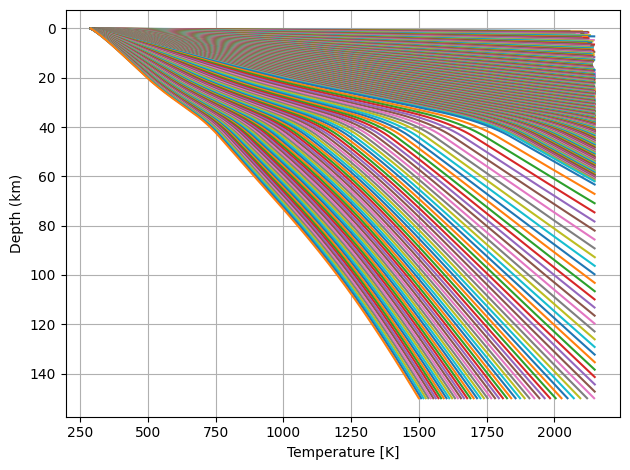

In [18]:
for geo in data:
    plt.plot(geo['T_K'], geo['depth_m']/km, label=f'{geo.attrs["q_W_m2"]*1000:.1f} mW/m²')

plt.xlabel('Temperature [K]')
plt.ylabel('Depth (km)')
plt.grid()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Explorando por integracion de euler

In [11]:
def calculate_geotherm_euler(R_planet, M_planet, qs_surface, Ts_surface, 
                       z_max=150e3, dz=500.0, heat_model='layered'):
    """
    Calcula el perfil térmico, de presión y flujo de calor.
    """
    # 1. Preparación de constantes y objetos
    g = (G * M_planet) / (R_planet**2)
    mineral_objs = gc.get_mineral_objects()
    boundaries = gc.scale_layer_boundaries(R_planet)
    
    # Listas para almacenar resultados
    depths = np.arange(0, z_max + dz, dz)
    T_profile = []
    P_profile = []
    q_profile = []
    rho_profile = []
    cond_profile = []

    # 2. Condiciones Iniciales
    T = Ts_surface
    P = 101325.0  # 1 atm en Pascales
    q = qs_surface
    
    print(f"Iniciando integración... g={g:.2f} m/s², qs={qs_surface*1e3:.1f} mW/m²")

    # 3. Bucle de Integración (Marcha hacia adelante)
    for z in depths:
        # A. Obtener composición y crear Composite de BurnMan para la densidad
        comp_modal_raw = gc.get_composition_at_depth(z, boundaries=boundaries)
        comp_modal = gc.normalize_modal_dict(comp_modal_raw)
        composite = gc.make_composite_from_modal(comp_modal, mineral_objs, P=P, T=T)
        
        # Seteamos el estado para obtener propiedades termodinámicas consistentes
        composite.set_state(P, T)
        rho = float(composite.density)
        
        # B. Calcular Conductividad Térmica Efectiva (VRH)
        # Usamos tu función que ya considera Lattice + Radiative
        k_eff = gc.lambda_effective_VRH(comp_modal, T, P)
        
        # C. Calcular Producción de Calor Radiogénico
        A = gc.radiogenic_heat_profile(z, model=heat_model, boundaries=boundaries)
        
        # Guardar valores actuales
        T_profile.append(T)
        P_profile.append(P)
        q_profile.append(q)
        rho_profile.append(rho)
        cond_profile.append(k_eff)
        
        # D. Paso de Integración (Actualización de variables)
        # dT/dz = q / k
        # dq/dz = A
        # dP/dz = rho * g
        
        dT = (q / k_eff) * dz
        dq = A * dz
        dP = (rho * g) * dz
        
        T += dT
        q -= dq  # El flujo disminuye hacia arriba, por eso restamos al bajar
        P += dP

    return {
        "z": depths, "T": np.array(T_profile), "P": np.array(P_profile),
        "q": np.array(q_profile), "rho": np.array(rho_profile), "k": np.array(cond_profile)
    }

In [12]:
resultados = calculate_geotherm_euler(
    R_planet=Re, 
    M_planet=Me, 
    qs_surface=0.065,  # 65 mW/m2 (promedio continental)
    Ts_surface=288.0, 
    z_max=150*km
)

Iniciando integración... g=9.80 m/s², qs=65.0 mW/m²


In [13]:
resultados_df = pd.DataFrame({
    "depth_km": resultados["z"] / km,
    "T_K": resultados["T"],
    "P_GPa": resultados["P"] / 1e9, 
    "q_mW_m2": resultados["q"] * 1e3,
    "rho_kg_m3": resultados["rho"],
})

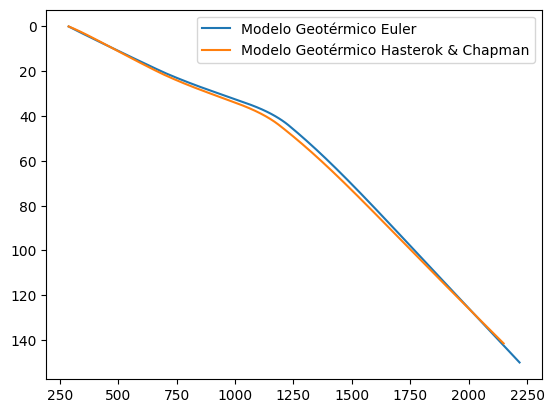

In [16]:
plt.plot(resultados['T'], resultados['z']/km, label ='Modelo Geotérmico Euler')
plt.plot(df_earth['T_K'], df_earth['depth_m']/km, label ='Modelo Geotérmico Hasterok & Chapman')
plt.gca().invert_yaxis()
plt.legend()